# Lecture 8: Transformers


Link to Google Colab file: 

In this notebook, I've trained multiple transformer encoder models along with a CNN baseline, on the **MagnaTagATune** dataset to perform multi-label genre classification. I evaluated all models using **ROC-AUC** and **PR-AUC**, and each transformer variant modified one architectural parameter to measure its effect on performance.

The transformer variations tested were: 

| Parameters        | Model 1: Baseline | Model 2: Half-Overlapping Kernels | Model 3: Positional Encoding | Model 4: CLS Token Averaging |
|-------------------|-------------------|-----------------------------------|------------------------------|------------------------------|
| `kernel`          | (8, 8)            | (8, 8)                            | (8, 8)                       | (8, 8)                       |
| `stride`          |     (8, 8)        |     (4, 4)                        |     (4, 4)                   |     (4, 4)                   |
| `n_blocks`        | 2                 | 2                                 | 2                            | 2                            |
| `emb_dim`         | 64                | 64                                | 64                           | 64                           |
| `n_heads`         | 4                 | 4                                 | 4                            | 4                            |
| `mlp_ratio`       | 2                 | 2                                 | 2                            | 2                            |
| `output_size`     | 10                | 10                                | 10                           | 10                           |
| `pos_enc_gain`    | 0                 | 0                                 | 0.5                          | 0.5                          |
| `cls_token_ratio` | 0                 | 0                                 | 0                            | 0.25                         |

## Notebook Contents:
- **Step 1:** Load MagnaTagATune Dataset
- **Step 2:** Feature Extraction
- **Step 3:** Define the Transformer Architecture
- **Step 4:** Train and Evaluate the Model


In [1]:
# !pip install torch
# !pip install torchcodec
# !pip install datasets[audio]==3
# !pip install tqdm
# !pip install scikit-learn
# !pip install matplotlib

In [2]:
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt

# AP - newly added imports
import os
import torchaudio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
import torchaudio.functional as ta_F
import torchaudio.transforms as T
import random
import math


from datasets import load_dataset
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, f1_score
from sklearn.exceptions import UndefinedMetricWarning
from torch.utils.data import DataLoader, Dataset
from torchaudio.transforms import MelSpectrogram, Resample
from tqdm.auto import tqdm, trange

# AP - newly added imports
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = torch.device("mps")  # Configure depending on the runtime

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 1: Load MagnaTagATune Dataset

As in previous labs, I load the audio files and metadata. However, for this notebook I moved `torchaudio.load` inot the dataset constructor so audio is loaded once in initialization instead of on every `__getitem__` call. This reduces repeated disk I/O and speeds up training at the cost of higher RAM usage.

In [5]:
# ==========================================================
# Load MagnaTagATune Annotations and Remove Corrupt Files
# ==========================================================

data_root = '../Lab 5'
mp3_root = '../Lab 5/mp3'

annotations = pd.read_csv(os.path.join(data_root, 'annotations_final.csv'), delimiter='\t')

# Identify empty MP3 files
empty_files = [
    file for file in annotations.mp3_path.values
    if file.lower().endswith('.mp3')
    and os.path.exists(os.path.join(mp3_root, file))
    and os.path.getsize(os.path.join(mp3_root, file)) == 0
]

print(f"Empty_files:\n{empty_files}")
print(len(annotations))

# Drop empty/corrupt files from the list of annotations
annotations = annotations[~annotations['mp3_path'].isin(empty_files)].reset_index(drop=True)

# Saving this version of annotations prior to genre filtering
all_annotations = annotations

print(len(annotations))

Empty_files:
['6/norine_braun-now_and_zen-08-gently-117-146.mp3', '8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3', '9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3']
25863
25860


In [6]:
# ==========================================================
# Filter Annotations for Only Relevant Genre Info
# ==========================================================

song_info = pd.read_csv(os.path.join(data_root, 'song_info.csv'), on_bad_lines='skip').fillna('')

# Splitting and cleaning genre information
def split_genres(col):
    genres = [g.strip().lower() for i in song_info[col].values for g in i.split(',') if g.strip()]
    return list(set(genres))

mp3_genre = split_genres('mp3genre')
magnatunegenres = split_genres('magnatunegenres')

# Aggregate a "complete" list of genres from both columns into a final list of all genres
all_genres =list(set(mp3_genre + magnatunegenres))

# Match the column names in Annotations_File.csv with the list of genres we've compiled above
annotations_labels = annotations.columns.values
genre_columns = [i for i in annotations_labels if i in all_genres]

# List of columns we will want to pull from the annotations_file.csv file
selected_columns = ['clip_id'] + genre_columns + ['mp3_path']
annotations = annotations[selected_columns]

# Remove rows that do not have any genre labels
annotations = annotations[~(annotations[genre_columns].sum(axis=1) == 0)]

annotations['track_folder'] = [i[0] for i in annotations['mp3_path'].str.split('/')]

# Print the removed columns to visually confirm they are not genre related
kept_columns = selected_columns + ['track_folder']
removed_columns = [col for col in all_annotations if col not in kept_columns]
print(f"Total original columns: {len(all_annotations)}")
print(f"Columns kept: {len(kept_columns)}")
print(f"Columns removed: {len(removed_columns)}")
print(f"\nRemoved columns:\n{removed_columns}")

Total original columns: 25860
Columns kept: 36
Columns removed: 155

Removed columns:
['no voice', 'singer', 'duet', 'plucking', 'bongos', 'female singing', 'clasical', 'sitar', 'chorus', 'female opera', 'male vocal', 'vocals', 'clarinet', 'heavy', 'silence', 'beats', 'men', 'woodwind', 'funky', 'no strings', 'chimes', 'foreign', 'no piano', 'horns', 'female', 'no voices', 'soft rock', 'eerie', 'spacey', 'quiet', 'no beat', 'banjo', 'electric', 'solo', 'violins', 'female voice', 'wind', 'happy', 'synth', 'no singing', 'middle eastern', 'trumpet', 'percussion', 'drum', 'airy', 'voice', 'repetitive', 'birds', 'space', 'strings', 'bass', 'harpsicord', 'male voice', 'girl', 'keyboard', 'acoustic', 'loud', 'classic', 'string', 'drums', 'electronic', 'not classical', 'chanting', 'no violin', 'not rock', 'no guitar', 'organ', 'no vocal', 'talking', 'weird', 'soprano', 'fast', 'acoustic guitar', 'electric guitar', 'male singer', 'man singing', 'classical guitar', 'violin', 'electro', 'tribal',

In [7]:
# ==========================================================
# Splitting Dataset Between Training / Validation / Testing
# ==========================================================

trainning_folders = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b' ]
val_folders = ['c']
test_folders = ['d','e','f']

train_split = annotations[annotations['track_folder'].isin(trainning_folders)]
val_split = annotations[annotations['track_folder'].isin(val_folders)]
test_split = annotations[annotations['track_folder'].isin(test_folders)]

In [8]:

# convert the train_split dataframe into a numpy array and pull only genre related columns (i.e. the labels)
y_train = train_split[train_split.columns[1:-2]].values
y_val = val_split[val_split.columns[1:-2]].values
y_test = test_split[test_split.columns[1:-2]].values

# convert the train_split dataframe into a numpy array and pull only metadata to identify the song (i.e. 'clip_id' and 'mp3_path')
X_train = train_split[[train_split.columns[0],train_split.columns[-2]]].values
X_val = val_split[[val_split.columns[0],val_split.columns[-2]]].values
X_test = test_split[[test_split.columns[0],test_split.columns[-2]]].values

print('X_train Shape:', X_train.shape)
print("y_train Shape:", y_train.shape)


X_train Shape: (13033, 2)
y_train Shape: (13033, 33)


## <i>Implementation Note:

Moving the loading step to the constructor minimizes repeated audio decoding and improves training throughput.

In [9]:
# ================================
# Establishing Data Loading Class
# ================================

class MagnaTagATune(Dataset):
    def __init__(self, file_paths_and_ids, labels, target_duration=3.0, sample_rate=16000, transform=None, root_dir='./'):
        
        self.sample_rate = sample_rate # Standardized sample rate
        self.audio_duration = target_duration
        self.file_paths_and_ids = file_paths_and_ids # This contains the X_train/val/test ['clip_id', 'mp3_path'], ...]
        self.target_samples = max(int(target_duration * sample_rate), 1024)
        self.root_dir = root_dir
        self.transform = transform
        
        self.labels = {}
        self.audio_cache = {}       # < --- stores loaded audio here 

        # Debug: basic info
        print(f"\nInitializing MagnaTagATune dataset with {len(file_paths_and_ids)} files.")
        print(f"Sample rate: {self.sample_rate}, Target samples: {self.target_samples}")

        # match labels with clip id for easier debugging
        for idx, (clip_id, relative_path) in enumerate(file_paths_and_ids):
            if not relative_path.startswith('mp3/'):
                relative_path = os.path.join('mp3', relative_path)
                
            audio_path = os.path.join(root_dir, relative_path)    
            self.labels[idx] = torch.tensor(labels[idx], dtype=torch.float32)  # <-- use encoded

            try:
                audio, sr = torchaudio.load(audio_path)
            except Exception as e:
                
                # Return zero audio + zero lables to avoid breaking DataLoader
                print(f"Failed to load {audio_path}: {e}")
                audio = torch.zeros((1, self.target_samples))
                sr = self.sample_rate
                
            # If the original audio has a different sample rate, resample it
            if sr != self.sample_rate:
                audio = torchaudio.functional.resample(audio, sr, self.sample_rate)
             
            audio = self._crop_or_pad(audio)
            
            # Save audio tensor
            self.audio_cache[idx] = audio

    def __len__(self):
        return len(self.file_paths_and_ids)

    def _crop_or_pad(self, waveform):
        num_samples = waveform.shape[-1]
        if num_samples > self.target_samples:
            # Random crop during training, center crop for evaluation (though this dataset uses it for both)
            start = random.randint(0, num_samples - self.target_samples)
            waveform = waveform[:, start:start + self.target_samples]
        elif num_samples < self.target_samples:
            # Pad with zeros at the end
            pad_amount = self.target_samples - num_samples
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))
        return waveform

    def __getitem__(self, idx):
        audio = self.audio_cache[idx]
        label = self.labels[idx]
        
        if self.transform:
            audio = self.transform(audio)

        return {"audio": audio, "labels": label}


In [10]:
# ==================================
# Implement Loading Data Functions
# ==================================

batch_size = 128 
target_duration = 3.0
sample_rate = 16000

train_transforms=None
val_transforms=None

# Instantiate the dataset using the corrected class
train_dataset = MagnaTagATune(X_train, y_train, target_duration=target_duration, transform=train_transforms, root_dir=data_root)
val_dataset = MagnaTagATune(X_val, y_val,target_duration=target_duration, transform=val_transforms,root_dir=data_root)
test_dataset = MagnaTagATune(X_test, y_test,target_duration=target_duration, transform=val_transforms,root_dir=data_root)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=False)

first_batch = next(iter(val_loader))




Initializing MagnaTagATune dataset with 13033 files.
Sample rate: 16000, Target samples: 48000

Initializing MagnaTagATune dataset with 1337 files.
Sample rate: 16000, Target samples: 48000

Initializing MagnaTagATune dataset with 3693 files.
Sample rate: 16000, Target samples: 48000


# Step 2: Feature Extraction

Mel-spectrograms were extracted as before. I made small adjustments to ensure all operations run on the correct device (CPU vs MPS/GPU), but the overall feature extraction pipeline remains the same.

In [11]:
class FeatureExtractor(nn.Module):
    """Log mel-spectrogram feature extractor.
    """

    def __init__(self, **kwargs):
        super().__init__()
        self.melspectrogram = MelSpectrogram(**kwargs)
        
    def to(self, device):
        # Move entire module
        super().to(device)

        # Move torchaudio internal buffers (very important!)
        for name, buf in self.melspectrogram.named_buffers():
            if buf is not None:
                setattr(self.melspectrogram, name, buf.to(device))

            return self

    def forward(self, x):
        if x.ndim == 3 and x.shape[1] == 1:  # (batch, 1, time)
            x = x.squeeze(1)                 # -> (batch, time)
        x = self.melspectrogram(x)

        # Log-compression
        x = torch.log10(1 + 1000 * x)
        return x

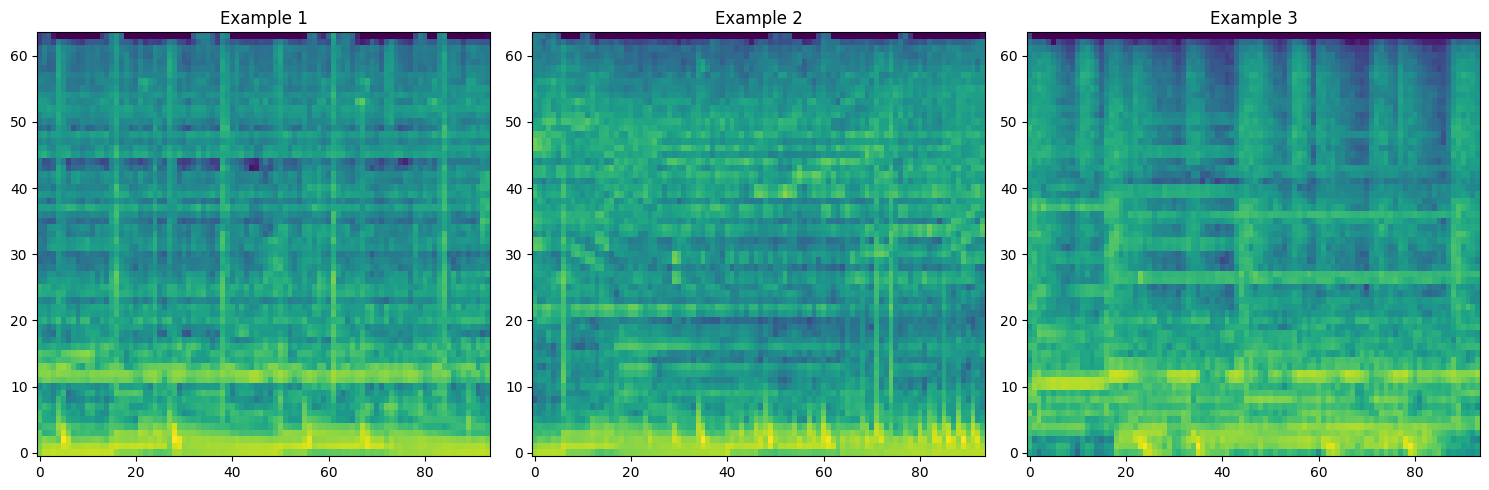

In [12]:
# ==================================
# Plotting Mel-Spectrogram Examples
# ==================================

feature_extractor = FeatureExtractor(n_mels=64, n_fft=1024).to(device)

# Fetch a batch of data
batch = next(iter(val_loader))
mel_specs = feature_extractor(batch["audio"].to(device)).detach().cpu().numpy()

# Visualize the first three mel-spectrograms in the batch
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].imshow(mel_specs[i], aspect="auto", origin="lower")
    axes[i].set_title(f"Example {i+1}") #  : {batch['natural_labels'][i]}")

plt.tight_layout()
plt.show()

In [13]:
n_classes = len(list(val_dataset.labels.values())[0])

print("Mel-spectrogram shape:", mel_specs.shape)
print("Number of classes:", n_classes)

Mel-spectrogram shape: (128, 64, 94)
Number of classes: 33


# Step 3: Define the Transformer Architecture

The baseline transformer includes patch extraction, positional encoding, a CLS token and a standard TransformerEncoder stack.

### Audio Input and Patch Extraction 
--------

First, the spectrogram (our input) is normalized to zero-mean unit standard deviation using `BatchNorm2d`. Then it's fed through a convolutional "patching" layer where raw pixels are transformed into a feature map of **patches** equal to the size of the kernel. Padding is included in the feature map so as to retain the original input image shape while centering feature values in the feature map. 

The output tensor has the shape: 

[**B**atches, **E**mbedding dimensions, **M** # of patches along the frequency axis, **T** # of patches along the time axis]

### Positional Encoding 
--------
Since self-attention doesn't inherently know where tokens sit within a sequence, we add sinusoidal positional encodings. This makes sure the position of each patch is taken into account when weights are calculated during the attention layers. The positional encoding uses sinusoidal waves values to encode the position of each token since using a continuous function allows the model to learn the positional encoding as a pattern which can be further extrapolated to longer sequence lengths than seen at train time.

In this implementation, I have used one positional encoding for the frequency axis (`pe_m`) and one for the time axis (`pe_t`). These tensors are then reshaped so they can combined into 1 large tensor with the embeddings for each patch. One of the model's parameters, `pos_enc_gain` which scales the positional information before it is added to the embeddings.  

In order to combine the positional encoding value from 2 dimensions into 1 positional value, we then flatten the last 2 dimensions of the tensor through matrix multiplication, and order the shape of the tensor by using the `.swapaxes()` method. The final outputted tensor has the shape: 

[**B**atches, **F*T** total # of patches, **E**mbedding dimensions]

### CLS Token Incorporation
--------
The CLS token (`self.cls`) is a learnable token added at the beginning or end of an input sequence which acts to summarize all the other embeddings defined through the attention mechanism and facilitates classification / prediction in the model output. The CLS token is initialized as a tensor filled with random values and is the same shape as any other token, meaning it has the same number of embedding dimensions, hence the code below:

`self.cls = nn.Parameter(torch.randn(1,1,self.emb_dim))`

Using the `nn.Parameter()` class initializes the CLS token as a parameter tensor meaning the values are also stored in model.parameters() making it easier to extract later. The CLS token is also normalized with standard deviation of 0.02 prior to incorporating in the model. 

The CLS token is pre-pended to every audio file (or Batch) prior to feeding the tensor of patches into the transformer encoder layer and therefore increases the sequence length (i.e. the number of patches) by 1: 

[**B**atches, **F*T** total # of patches + 1, **E**mbedding dimensions]

### Transformer Encoder Layer 
_________

This section is the heart of the transformer where attention is performed. Pytorch's `nn.TransformerEncoderLayer()` class is made up of self-attention layers and a feedforward network where embedding weights are updated based on neighboring tokens. In this function, we've defined the following parameters:

- `d_model` = Embedding Dimensions (`emb_dim`)
- `nhead` = Number of attention heads (`n_heads`)
- `dim_feedforward` = How many feature dimensions are in the hidden feed forward network (`emb_dim` * `mlp_ratio`)
- `drop_out` = Ratio of neurons which will be switched to = 0 to avoid overfitting, usually done in dense layers and in combination with non-linear activation functions (`0.01`)
- `norm_first` = Where normalization occurs in the order of operations, either before or after attention and feedforward layers (`True`)

Other parameters which we've left to default settings: 
- `bias` = Includes a bias term (`True`)
- `activation` = Function to use in intermediate layers (`relu`)
- `layer_norm_eps` = EPS value in layer normalization components (`1e-5`)

This function returns the tensor in the same shape as it was inputted: 

[**B**atches, **F*T** total # of patches + 1, **E**mbedding dimensions]

### CLS Token Classification & Mean Pooling 
---------

To evaluate the output of the Transformer, we must extract the CLS token before performing mean pooling over all the patch embeddings, which will then be fed into the dense classification head. 

Here, the `self.cls_token_ratio` parameter is applied when adding the CLS token embedding values back into the final averaged output, which scales the CLS token information before included in the weighted average. 

Since we average the embeddings across patches to get a final batch level average embedding, the weighted sum tensor shape changes to: 

[**B**atch, **E**mbedding dimensions]


### Dense Layer Classification
__________
The tensor is then normalized through `F.layer_norm` with size `emb_dim`, before being fed through 1 dense classification layer which remains the same shape. The tensor is then fed through a `F.relu` activation function before being fed into a final dense classification layer which converts the tensor into the pre-defined `output_size` (33 in this case for genres). 

In [ ]:
class Transformer(nn.Module):
    """Transformer model for audio classification.

    Args:
        kernel (tuple, optional): Kernel size for the convolutional patch embedding. Defaults to (8, 8).
        stride (tuple, optional): Stride for the convolutional patch embedding. Defaults to (8, 8).
        n_blocks (int, optional): Number of Transformer encoder blocks. Defaults to 2.
        emb_dim (int, optional): Embedding dimension. Defaults to 128.
        n_heads (int, optional): Number of attention heads. Defaults to 2.
        mlp_ratio (int, optional): Ratio of MLP hidden dimension to embedding dimension. Defaults to 2.
        output_size (int, optional): Number of output classes. Defaults to 10.
    """

    def __init__(
        self,
        kernel: tuple = (8, 8),
        stride: tuple = (8, 8),
        n_blocks: int = 2,
        emb_dim: int = 128,
        n_heads: int = 2,
        mlp_ratio: int = 2,
        output_size: int = 33,  # changed to 33 based on the 33 genre labels I've loaded in the MagnaTagATune dataset
        pos_enc_gain: float = 0.0,
        cls_token_ratio: float = 0.0,
    ):
        super().__init__()

        self.n_blocks = n_blocks
        self.emb_dim = emb_dim
        self.n_heads = n_heads
        self.mlp_ratio = mlp_ratio
        self.output_size = output_size
        self.pos_enc_gain = pos_enc_gain
        self.cls_token_ratio = cls_token_ratio

        self.norm = nn.BatchNorm2d(1)

        padding = kernel[0] // 2
        self.patching = nn.Conv2d(
            1, self.emb_dim, kernel_size=kernel, stride=stride, padding=padding
        )

        self.blocks = nn.ModuleList([
          nn.TransformerEncoderLayer(
              self.emb_dim,
              self.n_heads,
              dim_feedforward=self.emb_dim * self.mlp_ratio,
              dropout=0.1,
              norm_first=True,
          ) for _ in range(self.n_blocks)])

        # Defining the CLS token
        self.cls = nn.Parameter(torch.randn(1, 1, self.emb_dim))
        nn.init.normal_(self.cls, std=0.02)

        # two fully connected layers to convert the final embeddings into class logits
        self.fc1 = nn.Linear(self.emb_dim, self.emb_dim)
        self.fc2 = nn.Linear(self.emb_dim, self.output_size)

    def positional_encoding(self, seq_len):
        device=self.cls.device
        position = torch.arange(seq_len, dtype=torch.float32, device=device).unsqueeze(1)

        # computes the positions in terms of frequency of the sinusoidal wave used to encode positional offsets
        div_term = torch.exp(torch.arange(0, self.emb_dim, 2, dtype=torch.float32, device=device) * -(math.log(10000.0) / self.emb_dim))

        # create the positional encoding matrix with columns = emb_dim and rows = # of patches 
        pe = torch.zeros(seq_len, self.emb_dim, device=device)

        # fill the even indices in the matrix with sine, and fill the odd indices with cosine 
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe  # shape [seq_len, emb_dim]

    def forward(self, x):
        # Add embedding dimension convers [Batches, Freq, Time] -> [Batches, 1, Freq, Time]
        x = x.unsqueeze(1)

        # Normalize input to zero-mean unit std.
        x = self.norm(x)

        # Divide the signal into patches
        x = self.patching(x)  # [Batches, 1, freq, time] -> [batch, Emb_dim, M-patches along freq, T-patches along time]

        B, E, M, T = x.shape

        # Generate positional encodings for frequency and time
        pe_m = self.positional_encoding(M) # (M, E)
        pe_t = self.positional_encoding(T) # (T, E)

        # Reshape the positional encodings so they can be combined into 1 tensor and retain all the relevant info
        pe_m_reshaped = pe_m.transpose(0, 1).unsqueeze(0).unsqueeze(3) # (1, E, F, 1)
        pe_t_reshaped = pe_t.transpose(0, 1).unsqueeze(0).unsqueeze(2) # (1, E, 1, T)

        # Multiply the positional encoding with gain value which controls how much positioning impacts model weights
        x = x + self.pos_enc_gain * (pe_m_reshaped + pe_t_reshaped)

        # Combine the frequency and time axis positions so there is 1 position value 
        x = x.flatten(start_dim=2)  # [B, E, F, T] -> [B, E, F * T]
        x = x.swapaxes(1, 2)  # [B, E, F * T] -> [B, F * T, E]

        # Concatenate CLS token to the input of the transformer
        cls = self.cls.repeat(B, 1, 1)
        x = torch.cat([cls, x], dim=1)

        # Transformer backbone
        for block in self.blocks:
          x = block(x)

        # Classification on top of the CLS + average of the rest of tokens
        x_cls = x[:, 0, :]
        x_mean = x[:, 1:, :].mean(dim=1)
        x = self.cls_token_ratio * x_cls + (1 - self.cls_token_ratio) * x_mean

        # Dense classification head
        x = F.layer_norm(x, (self.emb_dim,))
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Step 4: Train and Evaluate the model 

Since MagnaTagATune is a multi-lable task, I replaced the cross-entropy loss function with `BCEWithLogitsLoss` and incorporated logits values to evaluate the model performance with ROC-AUC and PR-AUC values. 

`BCEWithLogitsLoss` is another form of cross entropy loss meant for binary classification tasks and, but can be adapted to this use case where we evaluate each labels performance independently from each other; perfect for a multi-label classification problem. This function uses a sigmoid function instead of softmax when converting logits to probabilities, and results in a peakier prediction, i.e. less entropy naturally. 

After training the model a few times and observing the evolution of training loss, I noticed the training loss plateaued early, so I reduced training from 100 to 50 epochs. 

## Results
------ 
I chose to use macro **ROC-AUC** and **PR-AUC** metrics to the evaluation since these metrics which treat each tag equally regardless of frequency. 


| Feature tested               | Test loss | Test Acc       | ROC-AUC   | PR-AUC    | Comments                                        |
| ---------------------------- | --------- | --------- | --------- | --------- | ----------------------------------------------------- |
| **CNN baseline**             | **0.102** | 0.478     | 0.881     | 0.294     | Baseline results                                        |
| **Transformer baseline**     | 0.110     | 0.456     | 0.881     | 0.290     | Slightly worse than CNN                               |
| **Half-overlapping kernels** | 0.105     | **0.483** | 0.882     | 0.296     | Better accuracy & PR-AUC → patching improvement helps |
| **Positional Encoding**      | 0.105     | 0.468     | **0.888** | 0.299     | Strong ROC-AUC meaning better ranking across classes        |
| **CLS token averaging**      | **0.102** | 0.465     | 0.885     | **0.300** | Best PR-AUC meaning better retrieval of rare tags           |


As expected, the inclusion of positional encoding and CLS token averaging improved PR-AUC and ROC-AUC scores. 

#### **Interpretation:**

- **Model 1:** Performed worse than the baseline CNN across almost all metrics, suggesting audio patching with no positional information is insufficient to make meaningful improvements 
- **Model 2:** Scored the best accuracy and received better than Model 1 in all other metrics. This is likely due to overlapping patches preserving some of the contextual information for each token, and creating a pseudo-positional encoding, and reduces information loss. 
- **Model 3:** Scored the highest in ROC-AUC, better PR-AUC than Model 2, but worse in accuracy. By incorporating the positional encoding, the ranking of labels across the dataset improved. It would be interesting to see the latent representations plotted to see if clustering also improved, which is what the high ROC-AUC score implies.
- **Model 4:** Scored the highest in PR-AUC and test loss meaning the model was able to identify rare tags better than in previous versions. This makes sense that including the CLS token with mean pooling brings more stability to the prediction / classification process.

Overall, adding positional information (Models 3–4) consistently improves performance compared to the pure patch-embedding transformer. 



In [15]:
def step(batch, loss_fn, model, device=device, optimizer=None, return_logits=False):
    x = batch["audio"].to(device)
    y = batch["labels"].to(device)

    # Forward
    x = feature_extractor(x)
    y_est = model(x)

    # Compute loss
    loss = loss_fn(y_est, y)
    step_loss = loss.item()

    # Compute metrics
    y_est = y_est.softmax(dim=1)
    y_int = torch.argmax(y, dim=1).cpu().numpy()
    y_est_int = torch.argmax(y_est, dim=1).cpu().numpy()

    step_acc = accuracy_score(y_int, y_est_int)

    # Backprop
    if optimizer:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # return logits (y_est) and labels (y) if requested 
    if return_logits:
        return step_loss, step_acc, y_est.detach(), y.detach()

    return step_loss, step_acc


def train(
    model,
    n_epochs=3,
    lr=0.001,
    device="mps",
    batch_size=32,
):
    # Use Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # changed the loss function here to be multi-label set
    loss_fn = torch.nn.BCEWithLogitsLoss()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # pbar = trange(n_epochs, desc="Training", total=n_epochs)
    for epoch in range(n_epochs):
        # Training loop

        model.train()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")

        total_loss, total_acc = 0, 0

        for batch in pbar:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                warnings.simplefilter("ignore", category=UndefinedMetricWarning)
                
                    
                step_loss, step_acc = step(
                    batch, 
                    loss_fn, 
                    model, 
                    device, 
                    optimizer, 
                    return_logits=False
                    )
                
                total_loss += step_loss
                total_acc += step_acc
                
                pbar.set_postfix({
                    "loss": f"{step_loss:.4f}",
                })
    
        train_loss = total_loss / len(train_loader)
        train_acc = total_acc / len(train_loader)

        # Validation loop
        model.eval()
        total_loss, total_acc = 0, 0
        
        with torch.no_grad():
            for batch in val_loader:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=UserWarning)
                    warnings.simplefilter("ignore", category=UndefinedMetricWarning)
                    
                    step_loss, step_acc = step(batch, loss_fn, model)
                    
                total_loss += step_loss
                total_acc += step_acc
                
            val_loss = total_loss / len(val_loader)
            val_acc = total_acc / len(val_loader)

        pbar.set_postfix({
            # "epoch": f"{epoch+1}",
            "train loss": f"{train_loss:.3f}",
            "train acc": f"{train_acc:.3f}",
            "val loss": f"{val_loss:.3f}",
            "val acc": f"{val_acc:.3f}",
        })


def test(model, device="mps", batch_size=32):
    # Test loop
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
    
    # changed the loss function here to be multi-label set
    loss_fn = torch.nn.BCEWithLogitsLoss()

    model.eval()
    total_loss, total_acc = 0, 0
    
    # Collect predictions & targets for ROC-AUC / PR-AUC
    all_logits = []
    all_targets = []
    
    with torch.no_grad():
        for batch in test_loader:
            
            step_loss, step_acc, logits, targets = step(batch, loss_fn, model, return_logits=True)
            total_loss += step_loss
            total_acc += step_acc
            
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())

    # Concatenate all batches
    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    # Convert logits → probabilities
    all_probs = torch.sigmoid(all_logits).numpy()
    all_targets_np = all_targets.numpy()

    # ----- Multi-label Metrics -----
    try:
        roc_auc = roc_auc_score(all_targets_np, all_probs, average="macro")
    except ValueError:
        roc_auc = float("nan")  # happens if a label has only one class present

    try:
        pr_auc = average_precision_score(all_targets_np, all_probs, average="macro")
    except ValueError:
        pr_auc = float("nan")

    # Standard test metrics
    test_loss = total_loss / len(test_loader)
    test_acc = total_acc / len(test_loader)

    print(
        f"test loss: {test_loss:.3f}, "
        f"test acc: {test_acc:.3f}, "
        f"ROC-AUC (macro): {roc_auc:.3f}, "
        f"PR-AUC (macro): {pr_auc:.3f}"
    )

In [16]:
class CNN(nn.Module):
    def __init__(
        self,
        kernel_size: int=3,
        pooling_size: int=4,
        dense_size: int=64,
        n_classes: int=33,
    ):
        super().__init__()
        self.dense_size = dense_size
        self.conv1 = nn.Conv2d(1, dense_size // 4, kernel_size=kernel_size, stride=1, padding=1)
        self.conv2 = nn.Conv2d(dense_size // 4, dense_size // 2, kernel_size=kernel_size, stride=1, padding=1)
        self.conv3 = nn.Conv2d(dense_size // 2, dense_size, kernel_size=kernel_size, stride=1, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=pooling_size, stride=pooling_size)
        self.fc1 = nn.Linear(dense_size, dense_size)
        self.fc2 = nn.Linear(dense_size, n_classes)  # Changes to be dynamic 

    def forward(self, x):
        if x.ndim == 3:
            x = x.unsqueeze(1)
        # x = x.unsqueeze(1)  # Add channel dimension: (32, 64, 94) -> (32, 1, 64, 94)
        x = self.pool(F.relu(self.conv1(x)))  # -> (32, 16, 64, 94) -> (32, 16, 16, 23)
        x = self.pool(F.relu(self.conv2(x)))  # -> (32, 32, 16, 23) -> (32, 32, 4, 5)
        x = self.pool(F.relu(self.conv3(x)))  # -> (32, 64, 4, 5) -> (32, 64, 1, 1)

        x = x.view(-1, self.dense_size)   # -> (32, 64)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x



In [18]:
model = CNN().to(device)

print("\nTraining CNN encoder")

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Transformer Trainable parameters: {num_params}")

train(model, n_epochs=50, device=device, batch_size=64)
test(model)


Training CNN encoder
Transformer Trainable parameters: 29601


Epoch 50/50: 100%|██████████| 204/204 [00:08<00:00, 24.62it/s, loss=0.0791]


test loss: 0.102, test acc: 0.478, ROC-AUC (macro): 0.881, PR-AUC (macro): 0.294


/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


In [41]:
for batch in train_loader:
    print("x:", batch["audio"].shape)
    print("y:", batch["labels"].shape, batch["labels"].dtype)
    break


x: torch.Size([128, 1, 48000])
y: torch.Size([128, 33]) torch.float32


In [52]:
model_1 = Transformer(
    n_blocks=2,
    emb_dim=64,
    n_heads=4,
).to(device)

print("Training Baseline Transformer encoder")

num_params = sum(p.numel() for p in model_1.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")

train(model_1, n_epochs=50, device=device, batch_size=32)



Training Baseline Transformer encoder
Number of trainable parameters: 77475


Epoch 50/50: 100%|██████████| 408/408 [00:25<00:00, 16.20it/s, loss=0.0937]


In [54]:
test(model_1)

test loss: 0.110, test acc: 0.456, ROC-AUC (macro): 0.881, PR-AUC (macro): 0.290


In [46]:
model_2 = Transformer(
    n_blocks=2,
    emb_dim=64,
    n_heads=4,
    stride=(4, 4),  # half-overlapped patches
).to(device)

print("Training Transformer encoder with half-overlapped patches (i.e. stride = (4, 4))")

num_params = sum(p.numel() for p in model_2.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")

train(model_2, n_epochs=100, device=device, batch_size=32)

Training Transformer encoder with half-overlapped patches (i.e. stride = (4, 4))
Number of trainable parameters: 77475


Epoch 100/100: 100%|██████████| 408/408 [00:32<00:00, 12.52it/s, loss=0.0647]


In [47]:
test(model_2)

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


test loss: 0.105, test acc: 0.483, ROC-AUC (macro): 0.882, PR-AUC (macro): 0.296


In [48]:
model_3 = Transformer(
    n_blocks=2,
    emb_dim=64,
    n_heads=4,
    stride=(4, 4),  # half-overlapped patches
    pos_enc_gain=0.5,  # positional encoding
).to(device)

print("Training Transformer encoder with half-overlapped patches and positional encoding")

num_params = sum(p.numel() for p in model_3.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")

train(model_3, n_epochs=50, device=device, batch_size=32)

Training Transformer encoder with half-overlapped patches and positional encoding
Number of trainable parameters: 77475


Epoch 50/50: 100%|██████████| 408/408 [00:32<00:00, 12.69it/s, loss=0.0843]


In [49]:
test(model_3)

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


test loss: 0.105, test acc: 0.468, ROC-AUC (macro): 0.888, PR-AUC (macro): 0.299


In [50]:
model_4 = Transformer(
    n_blocks=2,
    emb_dim=64,
    n_heads=4,
    stride=(4, 4),  # half-overlapped patches
    pos_enc_gain=0.5,  # positional encoding
    cls_token_ratio=0.25,  # cls token averaging
).to(device)

print("Training Transformer encoder")

num_params = sum(p.numel() for p in model_4.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")


train(model_4, n_epochs=50, device=device, batch_size=32)

Training Transformer encoder
Number of trainable parameters: 77475


Epoch 1/50:   0%|          | 0/408 [00:00<?, ?it/s]

Epoch 50/50: 100%|██████████| 408/408 [00:32<00:00, 12.54it/s, loss=0.0799]


In [51]:
test(model_4)

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem,

test loss: 0.102, test acc: 0.465, ROC-AUC (macro): 0.885, PR-AUC (macro): 0.300
